# 6. Backtesting strategies

**Question:** how would different strategies have performed, and how much of the difference is
luck?

Strategies are simulated monthly on the long-history EUR series (world equity, 10-year Bund, cash)
with 10 basis points of transaction costs. Targets for each month use only data available before
that month. All strategies start in the same month, after a 36-month warm-up for the
covariance-based ones.

In [1]:
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from investor_toolkit.plotting import apply_style

warnings.filterwarnings("ignore", category=FutureWarning)
apply_style()
pd.set_option("display.precision", 3)
pd.set_option("display.width", 120)
FIGURES = "../docs/figures"

from investor_toolkit import backtest as bt
from investor_toolkit import proxies
from investor_toolkit.plotting import plot_lines
from investor_toolkit.returns import annualized_return

In [2]:
long = proxies.long_history()
assets = long[["world_equity", "bund_10y", "cash"]]
base = {"world_equity": 0.6, "bund_10y": 0.4}
pair = ["world_equity", "bund_10y"]

strategies = [
    (bt.FixedWeights({"world_equity": 1.0}, name="100% equity"), bt.Rebalance(every=12)),
    (bt.FixedWeights(base, name="60/40 monthly"), bt.Rebalance(every=1)),
    (bt.FixedWeights(base, name="60/40 annual"), bt.Rebalance(every=12)),
    (bt.FixedWeights(base, name="60/40 5% band"), bt.Rebalance(every=None, band=0.05)),
    (bt.FixedWeights(base, name="60/40 never"), bt.Rebalance(every=None)),
    (bt.RiskParity(pair, name="risk parity"), bt.Rebalance(every=1)),
    (bt.MinimumVariance(pair, name="minimum variance"), bt.Rebalance(every=1)),
    (bt.TrendFollowing({"world_equity": 1.0}, name="trend, equity"), bt.Rebalance(every=1)),
    (bt.TrendFollowing(base, name="trend, 60/40"), bt.Rebalance(every=1)),
]
results = [bt.run_backtest(assets, s, rebalance=r, start=36, cost_bps=10) for s, r in strategies]
print(f"{results[0].returns.index[0]:%Y-%m} to {results[0].returns.index[-1]:%Y-%m}")
bt.compare(results, long["cash"])

2002-02 to 2026-08


,CAGR,volatility,sharpe,max_drawdown,calmar,turnover_per_year,cost_drag_per_year,final_value
100% equity,0.081,0.135,0.540,0.482,0.169,0.041,4.068e-05,6.836
60/40 monthly,0.062,0.084,0.587,0.277,0.224,0.230,2.304e-04,4.390
60/40 annual,0.064,0.083,0.620,0.263,0.244,0.117,1.169e-04,4.633
60/40 5% band,0.064,0.084,0.612,0.269,0.239,0.120,1.195e-04,4.637
60/40 never,0.067,0.083,0.643,0.227,0.293,0.041,4.068e-05,4.872
risk parity,0.052,0.061,0.627,0.189,0.276,0.251,2.505e-04,3.498
minimum variance,0.045,0.057,0.548,0.208,0.217,0.343,3.430e-04,2.953
"trend, equity",0.088,0.092,0.813,0.200,0.442,3.214,3.214e-03,8.011
"trend, 60/40",0.063,0.058,0.836,0.123,0.510,3.555,3.555e-03,4.476


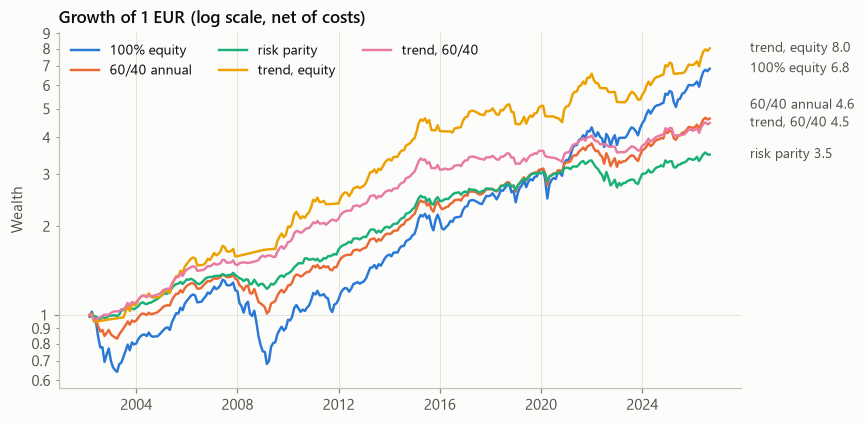

In [3]:
selected = ["100% equity", "60/40 annual", "risk parity", "trend, equity", "trend, 60/40"]
wealth = pd.DataFrame({r.name: r.wealth for r in results})[selected]
ax = plot_lines(
    wealth,
    log=True,
    title="Growth of 1 EUR (log scale, net of costs)",
    label_fmt=lambda v: f"{v:.1f}",
)
ax.set_ylabel("Wealth")
ax.figure.savefig(f"{FIGURES}/backtest_wealth.png")

**Rebalancing.** The 60/40 variants differ mainly in how far equities were allowed to drift. Over a
period in which equities beat bonds, never rebalancing ends with more equity and a higher return,
but then it is no longer a 60/40 portfolio: its risk drifted upward unmonitored. Calendar and band
rebalancing keep the risk profile constant at modest turnover.

**Trend following** (hold an asset only while it is above its 10-month moving average) avoided
most of the 2008 decline and the final leg of the 2000-2003 bear market, at the cost of much
higher turnover and lagging re-entries.

## Is the best strategy really better?

Nine strategies were tried, so the best Sharpe ratio is partly the result of selection. Two tools
address this:

* The **probabilistic Sharpe ratio (PSR)** is the probability that the true Sharpe ratio exceeds
  zero, given sample length, skewness and kurtosis (Bailey and Lopez de Prado, 2012).
* The **deflated Sharpe ratio (DSR)** replaces zero with the Sharpe ratio that the best of $N$
  worthless strategies would reach by luck (Bailey and Lopez de Prado, 2014).

In [4]:
cash = long["cash"]
excess = {r.name: r.returns - cash.reindex(r.returns.index) for r in results}
trial_std = np.std([e.mean() / e.std() for e in excess.values()], ddof=1)
pd.DataFrame(
    {
        name: {
            "sharpe (annual)": e.mean() / e.std() * np.sqrt(12),
            "PSR": bt.probabilistic_sharpe_ratio(e),
            "DSR": bt.deflated_sharpe_ratio(e, n_trials=len(results), trial_sr_std=trial_std),
        }
        for name, e in excess.items()
    }
).T

,sharpe (annual),PSR,DSR
100% equity,0.540,0.994,0.962
60/40 monthly,0.587,0.997,0.977
60/40 annual,0.620,0.998,0.984
60/40 5% band,0.612,0.998,0.983
60/40 never,0.643,0.999,0.988
risk parity,0.627,0.998,0.986
minimum variance,0.548,0.996,0.968
"trend, equity",0.813,1.000,0.999
"trend, 60/40",0.836,1.000,0.999


Every strategy beat cash with high probability, because both equities and bonds earned more than
cash over this period. The question that matters for choosing a strategy is the *difference*
between them. A paired block bootstrap gives a confidence interval for the difference in Sharpe
ratios, keeping the correlation between strategies and the autocorrelation of returns:

In [5]:
by_name = {r.name: r for r in results}
pd.DataFrame(
    {
        "trend, equity vs 100% equity": bt.bootstrap_difference(
            by_name["trend, equity"].returns, by_name["100% equity"].returns, n_boot=2000
        ),
        "risk parity vs 60/40 annual": bt.bootstrap_difference(
            by_name["risk parity"].returns, by_name["60/40 annual"].returns, n_boot=2000
        ),
        "trend, 60/40 vs 60/40 annual": bt.bootstrap_difference(
            by_name["trend, 60/40"].returns, by_name["60/40 annual"].returns, n_boot=2000
        ),
    }
).T

,difference,ci_low,ci_high,share_positive
"trend, equity vs 100% equity",0.321,-0.099,0.761,0.912
risk parity vs 60/40 annual,0.066,-0.195,0.340,0.685
"trend, 60/40 vs 60/40 annual",0.285,-0.096,0.695,0.913


The point estimates favour trend following, and most bootstrap samples agree, but the 95 %
intervals still include zero. Twenty-five years of monthly data contain only a handful of bear
markets, so even a large historical Sharpe advantage is not statistically conclusive. This is the
central limitation of any backtest.

## Lump sum or spread the investment?

Investing 1 EUR immediately in world equity vs moving it from cash into equity in 12 equal monthly
instalments, compared after 12 months, for every start month since 1999.

Lump sum ahead in 68% of 320 start months


count    320.000
mean       1.027
std        0.092
min        0.744
5%         0.837
50%        1.046
95%        1.153
max        1.229
dtype: float64

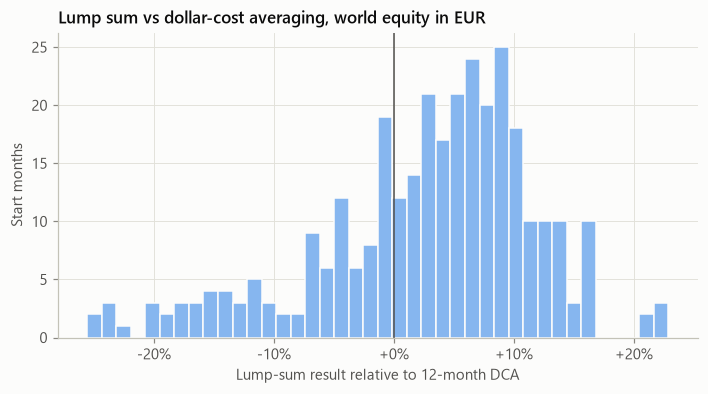

In [6]:
comparison = bt.lump_sum_vs_dca(long["world_equity"], long["cash"], months=12)
ratio = comparison["lump_sum"] / comparison["dca"]
share = comparison["lump_sum_wins"].mean()
print(f"Lump sum ahead in {share:.0%} of {len(comparison)} start months")
fig, ax = plt.subplots(figsize=(7.5, 3.6))
ax.hist(ratio - 1, bins=40, color="#86b6ef", edgecolor="#fcfcfb")
ax.axvline(0, color="#52514e", linewidth=1.0)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:+.0%}"))
ax.set_xlabel("Lump-sum result relative to 12-month DCA")
ax.set_ylabel("Start months")
ax.set_title("Lump sum vs dollar-cost averaging, world equity in EUR")
fig.savefig(f"{FIGURES}/lump_sum_vs_dca.png")
ratio.describe(percentiles=[0.05, 0.5, 0.95])

Because equities have a positive expected return, money waiting in cash usually costs return: the
lump sum wins in roughly two out of three start months. DCA narrows the spread of outcomes and
avoids the worst regret when a crash follows the investment, which can be a valid behavioural
reason to use it.

## A saver's view: time-weighted vs money-weighted return

In [7]:
saver = bt.run_backtest(
    assets,
    bt.FixedWeights({"world_equity": 1.0}),
    bt.Rebalance(every=12),
    initial=0.0,
    contributions=500.0,
    start=0,
    name="500 EUR per month",
)
pd.Series(
    {
        "months": len(saver.returns),
        "total invested": saver.contributions.sum(),
        "final value": saver.wealth.iloc[-1],
        "time-weighted return (CAGR)": annualized_return(saver.returns, 12),
        "money-weighted return (IRR)": saver.irr(),
    }
)

months                            331.000
total invested                 165500.000
final value                    780812.543
time-weighted return (CAGR)         0.079
money-weighted return (IRR)         0.098
dtype: float64

The time-weighted return measures the investment; the money-weighted return measures the saver's
experience. They differ because the amount invested grows over time, so later years weigh more
in the IRR.

**Takeaways**

* Rebalancing controls risk; its effect on return depends on the path.
* Trend following reduced drawdowns historically, but the evidence that it improves risk-adjusted
  returns is not statistically conclusive over this sample.
* Lump-sum investing beats spreading purchases about two-thirds of the time.
* Any backtest result needs a confidence interval and a correction for the number of strategies tried.